# Задание: Многовидовая 3D-реконструкция  
**Цель:** Восстановить трёхмерное облако точек по трём проекциям с неизвестных ракурсов.

**Срок:** дедлайн в 23:30 20 февраля.

# Входные данные
Вам дан список из трёх проекций (`data.pth`), а также массив цветов точек для удобства визуализации (`rgbs.pth`). Как можно видеть, каждый ракурс содержит лишь часть точек в облаке, а вашей целью будет совместить все эти части, получив трёхмерное облако точек.

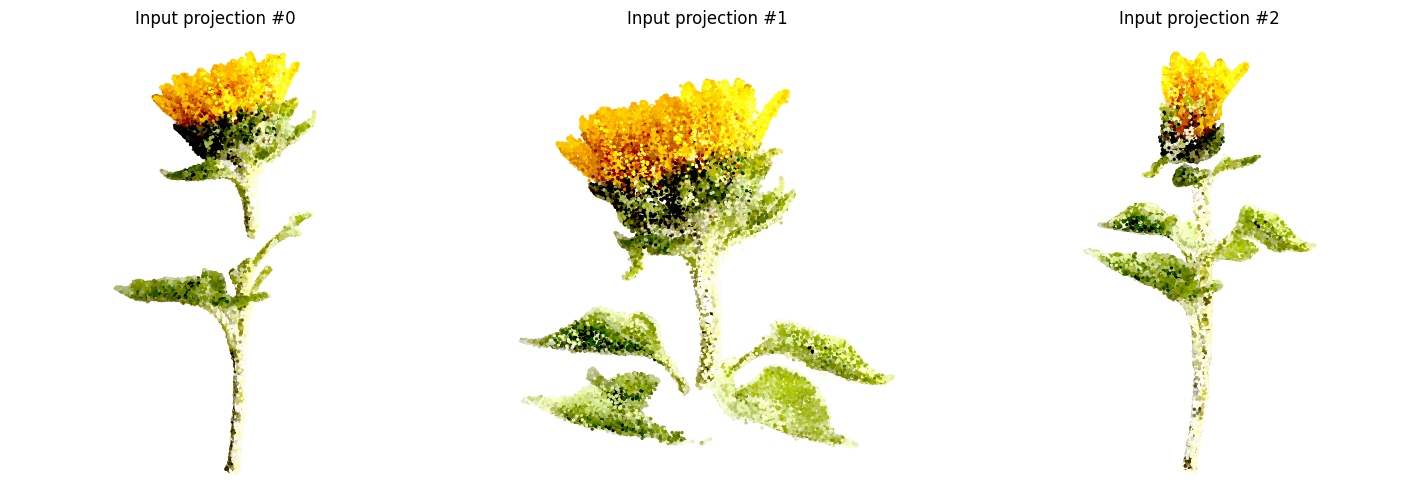

In [9]:
import torch
import matplotlib.pylab as plt

projections = torch.load('data.pth')
rgbs = torch.load('rgbs.pth')

fig, axes = plt.subplots(1, 3, figsize=(18,6))
for n_camera, (d, ax) in enumerate(zip(projections, axes.flatten())):
    xs, ys = d['coordinates'].T
    indices = d['ids']
    ax.scatter(xs, ys, c=rgbs[indices], s=2.)
    ax.axis('equal')
    ax.axis('off')
    ax.set_title(f'Input projection #{n_camera}')

Каждая проекция получена с неизвестного ракурса с помощью пинхол камеры с фокусным расстоянием 50мм, матрица внутренних параметров имеет следующий вид:

```python
# параметры объектива указывают в миллиметрах, а размер сенсора соответствет ширине кадра плёнки
f = 50
sensor_size = 36
# по ним строим матрицу внутренних параметров
K = torch.tensor([
    [2 * f / sensor_size, 0.0, 0.0],
    [0.0, 2 * f / sensor_size, 0.0],
    [0.0,                 0.0, 1.0]
])
```

Каждая проекция задана словарём. Поле `ids` содержит массив с номерами точек в исходном облаке (по ним можно найти соответствия между парой ракурсов), а поле `coordinates` неоднородные координаты в плоскости сенсора. Каждая точка видна как минимум с двух ракурсов.

```python
projection_example = {
    'ids': torch.tensor([0, 1, 2], dtype=torch.int64),
    'coordinates': torch.tensor([[0.1, 0.2], [0.2, 0.3], [0.3, 0.4]], dtype=torch.float32)
}
```

# Формат решения

Решение должно состоять из двух компонент:
1. Массив с реконструкцией исходного трёхмерного облака точек,
2. Отчёт в формате (PDF/Jupyter/Python/Markdown), с подробным описанием вашего метода и его реализацией.

## Облако точек

*Массив* будет использован для автоматизации проверки, но оценка за задание будет определяться в первую очередь на основе отчёта.
Ожидаемый формат массива - тензор размера $(N, 3)$.
```python
solution_example = torch.tensor([[0.1, 0.2, 0.0], [0.2, 0.3, 0.0], [0.3, 0.4, 0.0]], dtype=torch.float32)
```
Масштаб облака точек должен быть выбран исходя из предположения, что расстояние между первой и второй камерой равно *(условной)* единице.

## Отчёт

Вы свободны выбирать свой путь решения, но присланное решение не должно опираться на внешние реализации алгоритмов поиска фундаментальной матрицы, PnP, триангуляции и подобных. Иными словами, решение может использовать методы из библиотек torch`/`numpy, а более сложные алгоритмы должны быть реализованы внутри.

Для отладки и упрощения проверки рекомендуем включить в отчёт визуализации и тесты промежуточных шагов с пояснениями. Также полезной может оказаться визуализация облака точек:
```python
import open3d as o3d
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)
o3d.visualization.draw_geometries([pcd])
```

In [32]:
rgbs

tensor([[0.9922, 0.6902, 0.0000],
        [0.9922, 0.7922, 0.0000],
        [0.9922, 0.8275, 0.0000],
        ...,
        [0.9765, 0.6627, 0.0000],
        [0.9882, 0.6784, 0.0000],
        [0.9922, 0.7843, 0.0000]])

In [3]:
projections

[{'ids': tensor([    0,     1,     2,  ..., 76435, 76436, 76437]),
  'coordinates': tensor([[-0.1229,  0.8619],
          [-0.1898,  0.8531],
          [-0.1898,  0.8488],
          ...,
          [-0.3384,  0.7602],
          [-0.3313,  0.7568],
          [-0.3501,  0.7382]])},
 {'ids': tensor([    0,     1,     2,  ..., 76435, 76436, 76437]),
  'coordinates': tensor([[-0.3114,  0.8269],
          [-0.3808,  0.8178],
          [-0.3778,  0.8145],
          ...,
          [-0.4321,  0.7603],
          [-0.4245,  0.7571],
          [-0.4598,  0.7330]])},
 {'ids': tensor([   40,    41,    54,  ..., 76403, 76404, 76408]),
  'coordinates': tensor([[-0.0910,  0.9502],
          [-0.1234,  0.8968],
          [-0.0145,  0.9450],
          ...,
          [-0.3398,  0.2248],
          [-0.3323,  0.2317],
          [-0.3936,  0.2294]])}]

In [10]:
f = 50
sensor_size = 36
# по ним строим матрицу внутренних параметров
K = torch.tensor([
    [2 * f / sensor_size, 0.0, 0.0],
    [0.0, 2 * f / sensor_size, 0.0],
    [0.0,                 0.0, 1.0]
])

In [11]:
projection_example = {
    'ids': torch.tensor([0, 1, 2], dtype=torch.int64),
    'coordinates': torch.tensor([[0.1, 0.2], [0.2, 0.3], [0.3, 0.4]], dtype=torch.float32)
}

матрица внешний преобразований

In [9]:
projections[1]['ids']

tensor([    0,     1,     2,  ..., 76435, 76436, 76437])

In [8]:
K

tensor([[2.7778, 0.0000, 0.0000],
        [0.0000, 2.7778, 0.0000],
        [0.0000, 0.0000, 1.0000]])

In [10]:
projections[1]['coordinates'].max()

tensor(0.9547)

In [34]:
projections[1]['coordinates'].dtype

torch.float32

Так у нас есть координаты пикселей на пленке Функция для однородности координат - добавляет 1 к размерности и немного точности увеличив раз

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cuda')

In [13]:
def to_homogeneous(points):
    
    return torch.cat([points, torch.ones(points.shape[0], 1,device=device)], dim=1).to(torch.float64)

In [14]:
to_homogeneous(projections[0]['coordinates'].to(device))

tensor([[-0.1229,  0.8619,  1.0000],
        [-0.1898,  0.8531,  1.0000],
        [-0.1898,  0.8488,  1.0000],
        ...,
        [-0.3384,  0.7602,  1.0000],
        [-0.3313,  0.7568,  1.0000],
        [-0.3501,  0.7382,  1.0000]], device='cuda:0', dtype=torch.float64)

In [15]:
K_inv = torch.linalg.inv(K.to(torch.float64).to(device=device))
points_norm_cam0 = to_homogeneous(projections[0]['coordinates'].to(device)) @ K_inv.T

In [12]:
points_norm_cam0

tensor([[-0.0442,  0.3103,  1.0000],
        [-0.0683,  0.3071,  1.0000],
        [-0.0683,  0.3056,  1.0000],
        ...,
        [-0.1218,  0.2737,  1.0000],
        [-0.1193,  0.2725,  1.0000],
        [-0.1260,  0.2657,  1.0000]], device='cuda:0', dtype=torch.float64)

In [16]:
points_norm_cam1 = to_homogeneous(projections[1]['coordinates'].to(device)) @ K_inv.T

In [17]:
points_norm_cam1

tensor([[-0.1121,  0.2977,  1.0000],
        [-0.1371,  0.2944,  1.0000],
        [-0.1360,  0.2932,  1.0000],
        ...,
        [-0.1555,  0.2737,  1.0000],
        [-0.1528,  0.2726,  1.0000],
        [-0.1655,  0.2639,  1.0000]], device='cuda:0', dtype=torch.float64)

In [18]:
common_ids = torch.tensor(list(set(projections[0]['ids'].tolist()) & set(projections[1]['ids'].tolist())), dtype=projections[0]['ids'].dtype)
mask_cam0 = torch.isin(projections[0]['ids'], common_ids)
mask_cam1 = torch.isin(projections[1]['ids'], common_ids)

points0 = points_norm_cam0[mask_cam0]
points1 = points_norm_cam1[mask_cam1]

In [16]:
points1.shape[0]

37502

In [19]:
def get_essential_matrix(points_l, points_r):
    """
    Estimate Essential matrix E using eight-point algorithm
    points_l, points_r: Nx3 normalized camera coordinates (x, y, 1)
    """
    points_l = points_l.to(device)
    points_r = points_r.to(device)
    assert points_l.shape[0] == points_r.shape[0]
    assert points_l.shape[0] >= 8, f'Need at least 8 points, got {points_l.shape[0]}'
    assert points_l.shape[1] == points_r.shape[1] == 3, 'Expected Nx3 points'

    equations = torch.einsum('bi,bj->bij', points_r, points_l).view(-1, 9)

    _, _, Vh = torch.linalg.svd(equations)
    E = Vh[-1].view(3, 3).to(device)

    U, S, Vh = torch.linalg.svd(E)
    S_new = torch.tensor([1.0, 1.0, 0.0], dtype=E.dtype, device=device)
    E_normalized = U @ torch.diag(S_new) @ Vh
    return E_normalized

In [20]:
def compute_residuals(E, points_l, points_r):
    device = points_l.device
    E = E.to(device)
    points_l = points_l.to(device)
    points_r = points_r.to(device)
    residuals = torch.einsum('bi,ij,bj->b', points_r, E, points_l)
    return residuals

tensor(1.1572e-07, device='cuda:0', dtype=torch.float64)

In [21]:
E01=get_essential_matrix(points0,points1)

In [22]:
compute_residuals(E01,points0,points1).abs().max()

tensor(1.1572e-07, device='cuda:0', dtype=torch.float64)

In [23]:
def decompose_essential_matrix(E):
    U, _, Vh = torch.linalg.svd(E)

    if torch.linalg.det(U) < 0:
        U *= -1
    if torch.linalg.det(Vh) < 0:
        Vh *= -1

    W = torch.tensor([[0,-1,0],[1,0,0],[0,0,1]], dtype=E.dtype, device=E.device)

    # 4 варианта
    R1, R2 = U @ W @ Vh, U @ W.T @ Vh
    t = U[:,2]
    return [(R1, t), (R1, -t), (R2, t), (R2, -t)]

In [27]:
Rt_candidates=decompose_essential_matrix(E01)

In [25]:
def triangulate_points(points1, points2, R, t):
    device = points1.device
    t = t.view(3,1)

    P1 = torch.eye(3,4, device=device)
    P2 = torch.cat([R, t], dim=1)

    X_list = []
    for i in range(points1.shape[0]):
        x1 = points1[i].view(3,1)
        x2 = points2[i].view(3,1)

        A = torch.stack([
            x1[0]*P1[2]-P1[0],
            x1[1]*P1[2]-P1[1],
            x2[0]*P2[2]-P2[0],
            x2[1]*P2[2]-P2[1]
        ])
        _, _, Vh = torch.linalg.svd(A)
        X = Vh[-1]
        X = X[:3] / X[3] if X.shape[0]==4 else X
        X_list.append(X)

    return torch.stack(X_list)

In [26]:
max_positive = -1
best_R, best_t = None, None

for R, t in Rt_candidates:
    X = triangulate_points(points0, points1, R, t)
    # z-координата в первой камере >0
    z1 = X[:,2]
    # z-координата во второй камере
    X2 = (R @ X.T + t.view(3,1)).T
    z2 = X2[:,2]

    positive = ((z1>0) & (z2>0)).sum().item()
    if positive > max_positive:
        max_positive = positive
        best_R, best_t = R, t


In [28]:
best_R

tensor([[ 0.9237,  0.0990,  0.3701],
        [-0.1518,  0.9815,  0.1164],
        [-0.3518, -0.1637,  0.9217]], device='cuda:0', dtype=torch.float64)

In [29]:
best_t

tensor([-0.9432, -0.2718,  0.1910], device='cuda:0', dtype=torch.float64)

In [30]:
points_3d = triangulate_points(points0, points1, best_R, best_t)

In [37]:
points_3d

tensor([[-0.0888,  0.6227,  2.0067],
        [-0.1362,  0.6120,  1.9927],
        [-0.1365,  0.6105,  1.9979],
        ...,
        [-0.2601,  0.5844,  2.1355],
        [-0.2550,  0.5827,  2.1385],
        [-0.2655,  0.5598,  2.1066]], device='cuda:0', dtype=torch.float64)

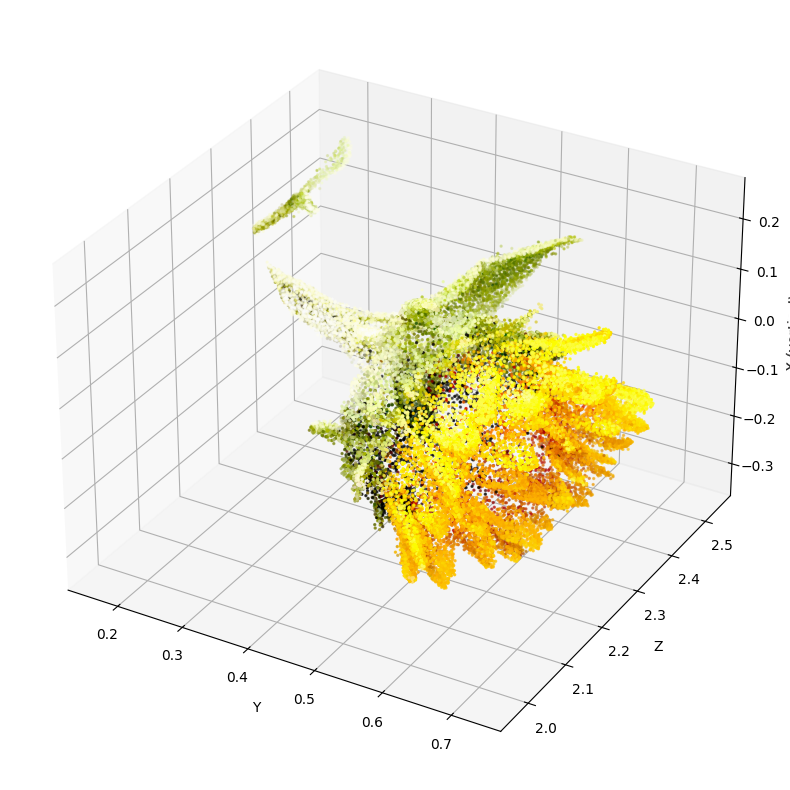

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt

points = points_3d.detach().cpu().numpy()

ids_used = projections[0]['ids'][mask_cam0]
colors = rgbs[ids_used].detach().cpu().numpy()

if colors.max() > 1.0:
    colors = colors / 255.0

X = points[:, 0]
Y = points[:, 1]
Z = points[:, 2]

# --- ПЕРЕСТАНОВКА ОСЕЙ ---
Xm = Y        # вправо
Ym = Z        # глубина
Zm = X        # вверх (вертикаль)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Xm, Ym, Zm, c=colors, s=2)

ax.set_xlabel("Y")
ax.set_ylabel("Z")
ax.set_zlabel("X (vertical)")

# равный масштаб
max_range = np.array([Xm.max()-Xm.min(),
                      Ym.max()-Ym.min(),
                      Zm.max()-Zm.min()]).max() / 2.0

mid_x = (Xm.max()+Xm.min()) * 0.5
mid_y = (Ym.max()+Ym.min()) * 0.5
mid_z = (Zm.max()+Zm.min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout()
plt.show()
